## 1 - Exploración inicial
Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos customer_data.csv y analice las variables Age e Income mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

               Age         Income
count  2000.000000    2000.000000
mean     35.909000  120954.419000
std      11.719402   38108.824679
min      18.000000   35832.000000
25%      27.000000   97663.250000
50%      33.000000  115548.500000
75%      42.000000  138072.250000
max      76.000000  309364.000000


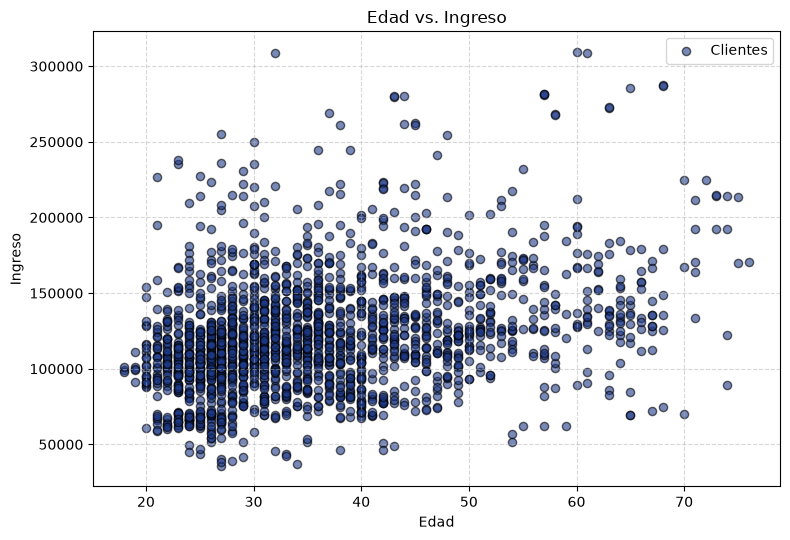

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

clientes_df = pd.read_csv("./data/customer_data.csv")

print(clientes_df[['Age', 'Income']].describe())

plt.figure(figsize = (8, 5.5))

plt.scatter(
    clientes_df['Age'],
    clientes_df['Income'],
    color = '#1E3A8A',
    alpha=0.6,
    edgecolor='k',
    s=35, 
    label = 'Clientes'
)


plt.title('Edad vs. Ingreso')
plt.xlabel('Edad')
plt.ylabel('Ingreso')
plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

No pueden observarse grupos claramente delimitados. Si bien no todos los datos están agrupados en un solo espacio, no existen vacíos significativos que delimiten dos grupos. Sin embargo hay una gran concentración notable en la esquina inferior izquierda y una mayor dispersión en la parte superior derecha.

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

RESULTADOS
 K   Inercia Silueta Promedio
 1 4000.0000              NaN
 2 2260.2037           0.4424
 3 1647.5540           0.4394
 4 1281.1447           0.3503
 5 1024.2394           0.3648
 6  865.9056           0.3555
 7  751.3056           0.3556
 8  665.0295           0.3561
 9  582.9290           0.3617
10  511.2343           0.3674


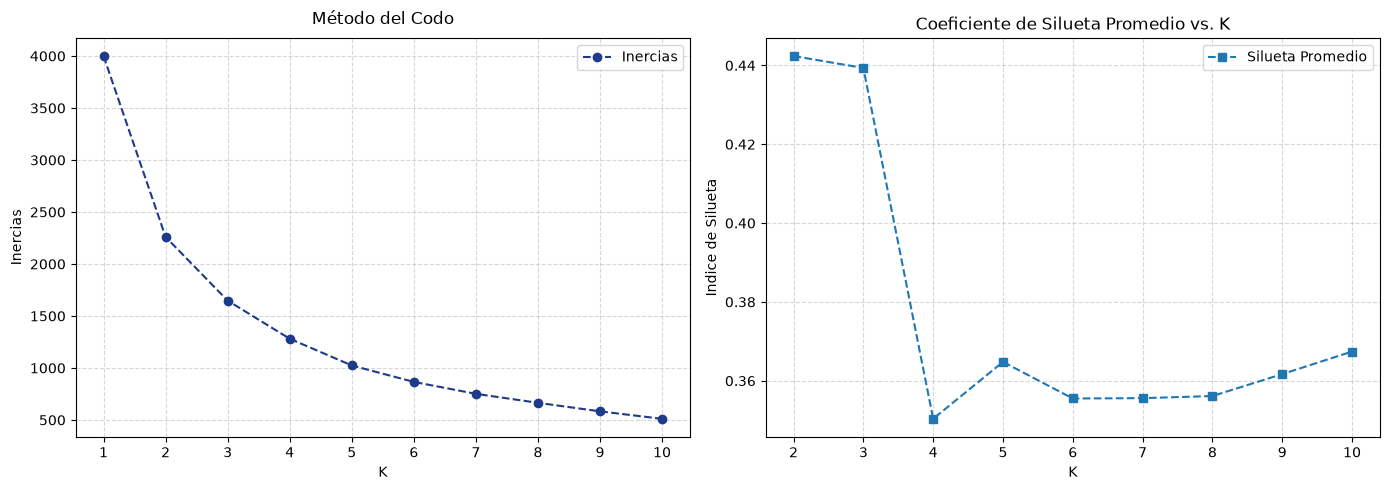

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clientes_df = pd.read_csv('./data/customer_data.csv')

columnas = clientes_df[['Age', 'Income']]

#Escalamos
scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

k_rango = range(1,11)
inercias = []
coeficientes_silueta = []

for k in k_rango:
    kmeans =  KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(columnas_escaladas)

    inercias.append(kmeans.inertia_)

    if k>=2:
        coeficiente = silhouette_score(columnas_escaladas, kmeans.labels_)
        coeficientes_silueta.append(coeficiente)
    else:
        coeficientes_silueta.append(np.nan)
df_resultados = pd.DataFrame({
    'K': k_rango,
    'Inercia': inercias,
    'Silueta Promedio': coeficientes_silueta
})

print("RESULTADOS")
print(df_resultados.to_string(index = False, formatters={
    'Inercia': '{:.4f}'.format,
    'Silueta Promedio': lambda x: '{:.4f}'.format(x) if not np.isnan(x) else 'N/A'
}))



fig, axs = plt.subplots(1, 2, figsize=(14, 5))
#Grafica de Codo
axs[0].plot(k_rango, inercias, marker='o', linestyle = '--', color='#1E3A8A', label='Inercias')
axs[0].set_title('Método del Codo', pad = 10)
axs[0].set_xlabel('K')
axs[0].set_ylabel('Inercias')
axs[0].set_xticks(k_rango)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

#Coeficiente de Silueta vs. K
axs[1].plot(list(range(2,11)), coeficientes_silueta[1:], marker='s', linestyle='--', label='Silueta Promedio')
axs[1].set_title('Coeficiente de Silueta Promedio vs. K')
axs[1].set_xlabel('K')
axs[1].set_ylabel('Indice de Silueta')
axs[1].set_xticks(range(2,11))
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

Considerando los datos observados, se infiere que los mejores valores para K son:
* K = 2: tiene el coeficiente de silueta proedio más alto, indicando que es el valor que presenta mejor coehsión interna y mejor separación entre los grupos.
* K = 3: mantiene un coeficiente de silueta promedio alto (0,4394) y presenta un punto de inflexión en la gráfica de Inercia vs. K, demostrando que allí la curva empieza a aplanarse y la reducción de inercia empieza a ser marginal en dicho punto

## 4. Análisis de los diagramas de silueta
El coeficiente promedio resume el resultado en un único número, pero no permite observar cómo se comportan las observaciones dentro de cada cluster.

Construya diagramas de silueta para  K=2 ,  K=3 ,  K=4  y  k=5 .

Interprételo de acuerdo a los criterios vistos en la notebook de práctica.

Utilice esta información para complementar la elección de  K .

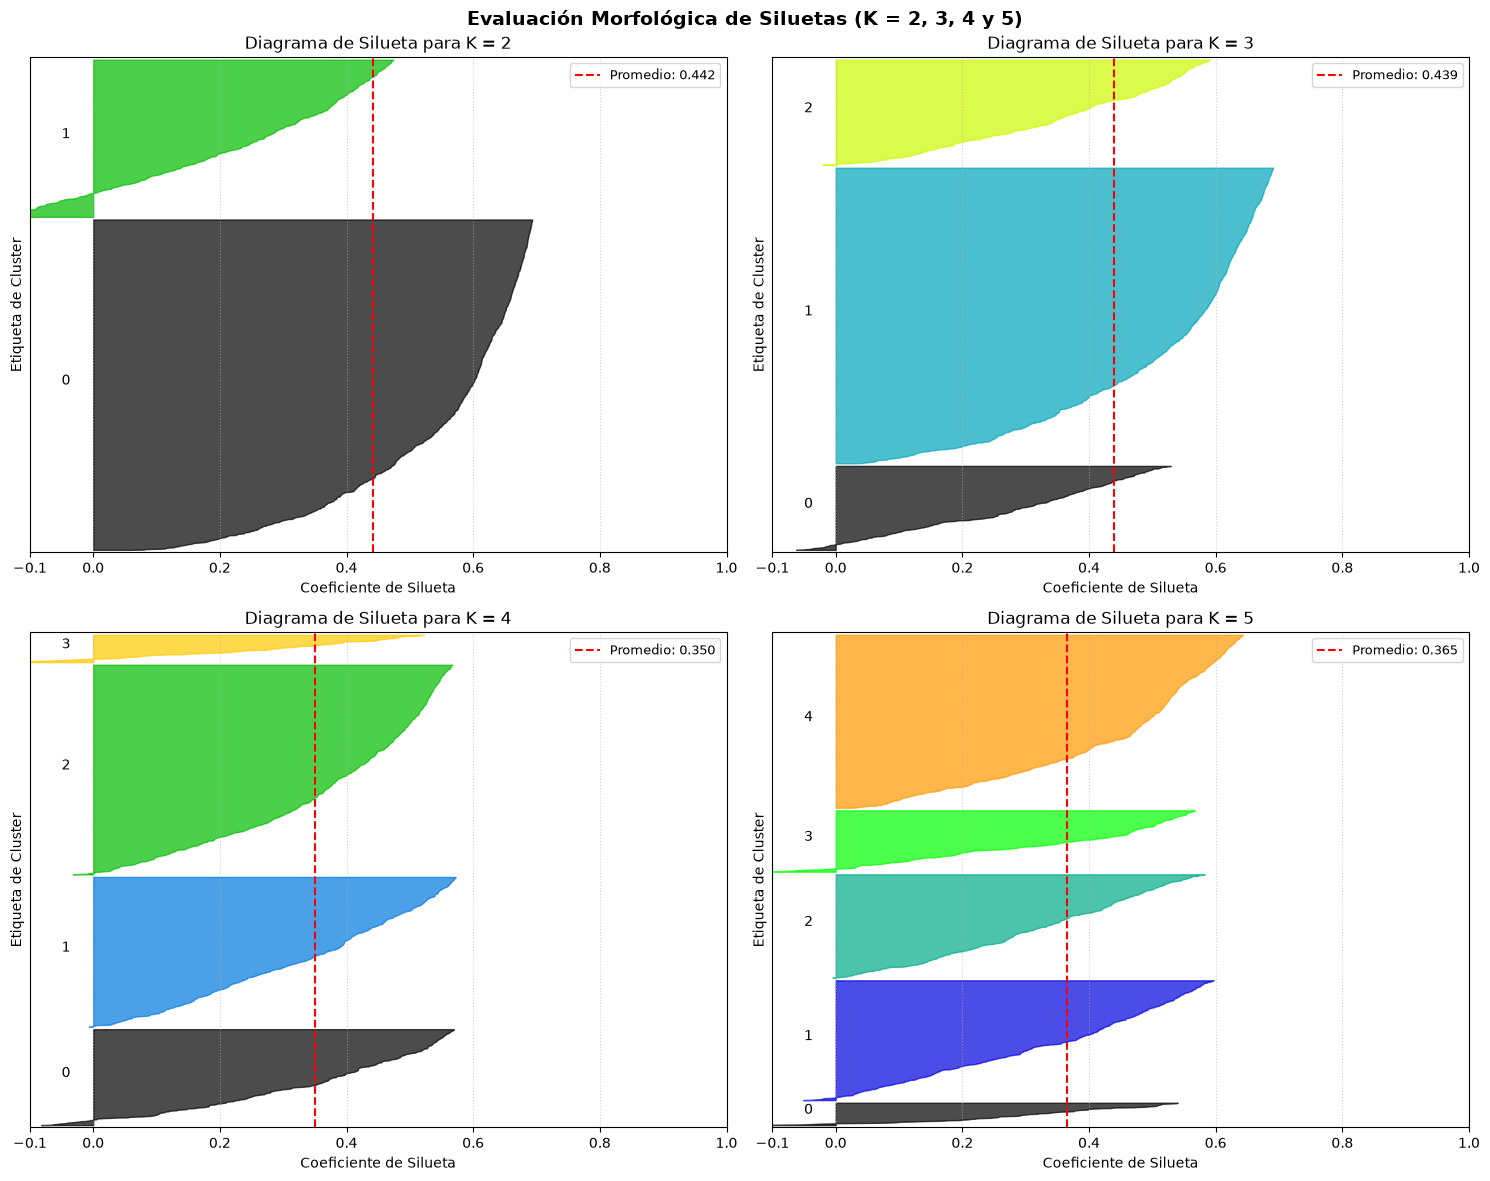

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

range_n_clusters = [2, 3, 4, 5]

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.ravel()

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axs[idx]
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(columnas_escaladas) + (n_clusters + 1) * 10])
    
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(columnas_escaladas)
    
    silhouette_avg = silhouette_score(columnas_escaladas, cluster_labels)
    sample_silhouette_values = silhouette_samples(columnas_escaladas, cluster_labels)
    
    y_lower = 10 
    for i in range(n_clusters): 
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"Diagrama de Silueta para K = {n_clusters}")
    ax.set_xlabel("Coeficiente de Silueta")
    ax.set_ylabel("Etiqueta de Cluster")

    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=1.5,
               label=f"Promedio: {silhouette_avg:.3f}")

    ax.set_yticks([]) 
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc="upper right", fontsize=9)

plt.suptitle("Evaluación Morfológica de Siluetas (K = 2, 3, 4 y 5)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


        



Complementando las conclusiones a las que se llegó anteriormente, se puede observar que:
- k=2 tiene un desequilibrio notable en el volumen de los grupos siendo el 0 quien agrupa la gran mayoria de los datos. En el cluster 1 se observan coeficientes negativos.
- k=3 presenta una estructura más estable y consistente, el cluster 1 es más voluminosos pero se logra que se supere el coeficiente promedio. 
- k= 4 y 5 tienen una menor calidad y el promedio general cae y tiene importantes desequilibrios entre grupos. 


## 5. Segmentación final con K-Means
Ajuste un modelo K-Means utilizando el valor de K seleccionado.

Obtenga la etiqueta asignada a cada cliente.
Represente los clusters utilizando las variables originales Age e Income.
Calcule los centroides y represéntelos en el gráfico.
Interprete qué representan los grupos obtenidos.
Recuerde que los números asignados a los clusters son identificadores arbitrarios: Cluster 0 no implica que ese grupo sea menor o más importante que Cluster 1.

Agrupamiento
 Cluster  Tamano Edad_Promedio Ingreso_Promedio Masculino_Ratio Casado_Ratio  Educacion_Mediana  Ocupacion_Mediana  Ciudad_Mediana
       0     347    35.89 años      $175,604.58           74.6%        39.5%                1.0                2.0             1.0
       1    1218    29.71 años      $101,742.81           45.1%        56.7%                1.0                1.0             0.0
       2     435    53.28 años      $131,152.44           63.9%        37.9%                2.0                1.0             1.0


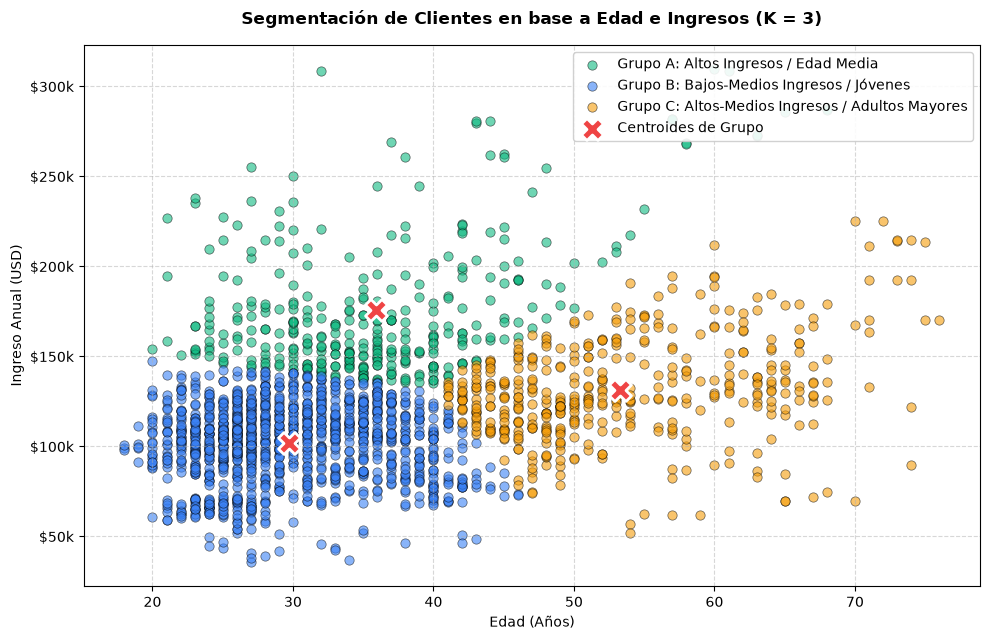

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
clientes_df['Cluster'] = kmeans.fit_predict(columnas_escaladas)

centroides_escalados = kmeans.cluster_centers_
centroides_reales = scaler.inverse_transform(centroides_escalados)


# Agrupamos por cluster y calculamos métricas clave para perfilar
perfiles = clientes_df.groupby('Cluster').agg(
    Tamano=('ID', 'count'),
    Edad_Promedio=('Age', 'mean'),
    Ingreso_Promedio=('Income', 'mean'),
    Masculino_Ratio=('Sex', lambda x: (x == 0).mean()), 
    Casado_Ratio=('Marital status', 'mean'),           
    Educacion_Mediana=('Education', 'median'),          
    Ocupacion_Mediana=('Occupation', 'median'),         
    Ciudad_Mediana=('Settlement size', 'median')        
).reset_index()

print("Agrupamiento")
print(perfiles.to_string(index=False, formatters={
    'Edad_Promedio': '{:.2f} años'.format,
    'Ingreso_Promedio': '${:,.2f}'.format,
    'Masculino_Ratio': '{:.1%}'.format,
    'Casado_Ratio': '{:.1%}'.format
}))


plt.figure(figsize=(10, 6.5))
colores = {0: '#10B981', 1: '#3B82F6', 2: '#F59E0B'}
nombres_grupos = {
    0: 'Grupo A: Altos Ingresos / Edad Media',
    1: 'Grupo B: Bajos-Medios Ingresos / Jóvenes',
    2: 'Grupo C: Altos-Medios Ingresos / Adultos Mayores'
}

for c_id in sorted(clientes_df['Cluster'].unique()):
    sub_df = clientes_df[clientes_df['Cluster'] == c_id]
    plt.scatter(
        sub_df['Age'], 
        sub_df['Income'], 
        color=colores[c_id],
        alpha=0.6, 
        edgecolors='k', 
        linewidths=0.5,
        s=45,
        label=nombres_grupos[c_id]
    )

plt.scatter(
    centroides_reales[:, 0], 
    centroides_reales[:, 1], 
    color='#EF4444', 
    marker='X', 
    s=250, 
    edgecolors='white', 
    linewidths=2,
    zorder=10,
    label='Centroides de Grupo'
)

plt.title('Segmentación de Clientes en base a Edad e Ingresos (K = 3)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=10)
plt.ylabel('Ingreso Anual (USD)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k')
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

## 6. Caracterización de los segmentos
Agregue las etiquetas de K-Means al conjunto de datos original y describa cada cluster utilizando las características disponibles.

Para cada grupo analice:

cantidad de clientes;
edad media y mediana;
ingreso medio y mediano;
distribución por género;
estado civil;
nivel educativo;
ocupación;
tamaño de la ciudad de residencia.
A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de pandas para esta tarea.

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clientes_df['Cluster'] = kmeans.fit_predict(columnas_escaladas)

perfiles = clientes_df.groupby('Cluster').agg(
    Cantidad_Clientes=('ID', 'count'),
    Edad_Media=('Age', 'mean'),
    Edad_Mediana=('Age', 'median'),
    Ingreso_Medio=('Income', 'mean'),
    Ingreso_Mediana=('Income', 'median'),
    Proporcion_Hombres=('Sex', lambda x: (x == 0).mean()),  # Sex: 0 = Hombre
    Proporcion_Casados=('Marital status', 'mean'),         # Marital status: 1 = Casado
    Educacion_Mediana=('Education', 'median'),              # 0=sin, 1=secundario, 2=univ, 3=posgrado
    Ocupacion_Mediana=('Occupation', 'median'),             # 0=desempleado, 1=empleado, 2=directivo/mág.
    Ciudad_Mediana=('Settlement size', 'median')            # 0=pequeña, 1=mediana, 2=grande
).reset_index()


print("CARACTERIZACIÓN")
print(perfiles.to_string(index=False, formatters={
    'Edad_Media': '{:.2f} años'.format,
    'Edad_Mediana': '{:.1f} años'.format,
    'Ingreso_Medio': '${:,.2f}'.format,
    'Ingreso_Mediana': '${:,.2f}'.format,
    'Proporcion_Hombres': '{:.1%}'.format,
    'Proporcion_Casados': '{:.1%}'.format
}))

CARACTERIZACIÓN
 Cluster  Cantidad_Clientes Edad_Media Edad_Mediana Ingreso_Medio Ingreso_Mediana Proporcion_Hombres Proporcion_Casados  Educacion_Mediana  Ocupacion_Mediana  Ciudad_Mediana
       0                347 35.89 años    35.0 años   $175,604.58     $162,827.00              74.6%              39.5%                1.0                2.0             1.0
       1               1218 29.71 años    29.0 años   $101,742.81     $104,405.50              45.1%              56.7%                1.0                1.0             0.0
       2                435 53.28 años    51.0 años   $131,152.44     $127,825.00              63.9%              37.9%                2.0                1.0             1.0


Se elaboran los siguientes perfiles comerciales de cada cluster de clientes:
- 0: Es el segmento con mayor poder adquisitivo, lo integra mayorment4e hombres jóvenes-adultos (74.6% con edad media de 36 años) residentes de ciudades grandes/medianas con un ingreso anual promedio de $175,604.58, ocupaciones como puestos directivos, gerenciales o de ealta especialización. Tienen tasas de matrimonio regulares (39.5%)
- 1: Cluster mayoritario, conformado por ambos sexos (ligera mayoria de mujeres 54,9%) y edad media de 29,7 años. Ingreso promedio de $101,742.81 con la tasa más alta de casados (56.7%), educación secundaria y trabajan en puestos operativos o calificación media, viven en ciudades pequeñas o áreas ruarles. 
- 2: Segmento con mayor esttabilidad temporal. Adultos mayores y jubilados (edad media 53.3 años) con predominancia masculina (63.9%)
Tienen un ingreso medio-alto muy estable ($131,152.44) con alto nivel educativo. Viven en ciudades de tamaño mediano con baja tasa de matrimonio (37.9)

### 7. Agrupamiento jerárquico aglomerativo

Aplique agrupamiento jerárquico sobre las mismas variables estandarizadas.

1. Construya un dendrograma utilizando distancia Euclídea y enlace completo (`complete`).
2. Analice las últimas fusiones del árbol y proponga un nivel de corte.
3. Obtenga una partición con un número de clusters igual al obtenido con k-means.
4. Calcule el coeficiente de silueta para ese número de clusters.
5. Compare visualmente esta solución con la obtenida mediante K-Means.

Últimas Fusiones
Paso 1999: Clúster 3996 + Clúster 3997 -> Distancia de fusión: 7.7234 (2000 elementos)
Paso 1998: Clúster 3993 + Clúster 3995 -> Distancia de fusión: 6.2764 (1744 elementos)
Paso 1997: Clúster 3989 + Clúster 3994 -> Distancia de fusión: 5.1663 (256 elementos)
Paso 1996: Clúster 3988 + Clúster 3992 -> Distancia de fusión: 4.7956 (276 elementos)
Paso 1995: Clúster 3977 + Clúster 3983 -> Distancia de fusión: 3.5990 (27 elementos)


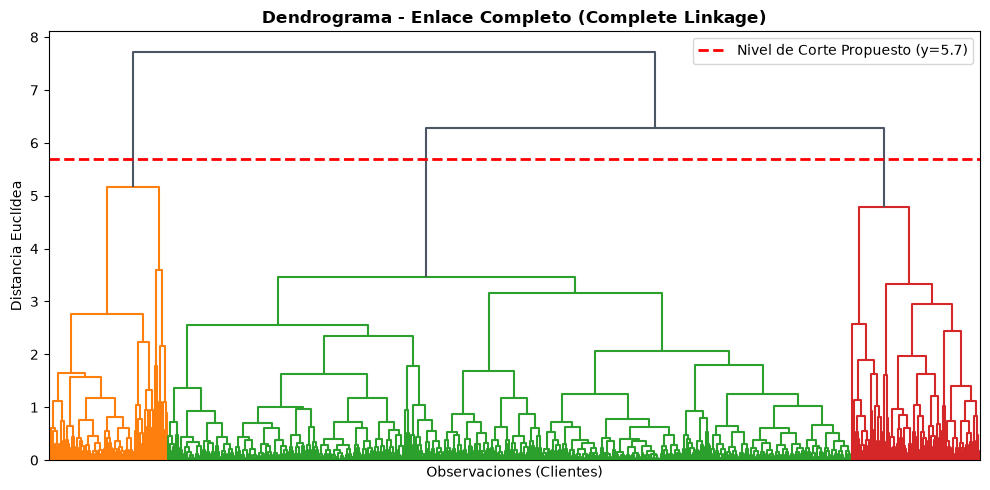

Coefiecientes de Silueta Promedio con K = 3
Coeficiente de Silueta - K-Means: 0.4394
Coeficiente de Silueta - Jerárquico Aglomerativo: 0.4021


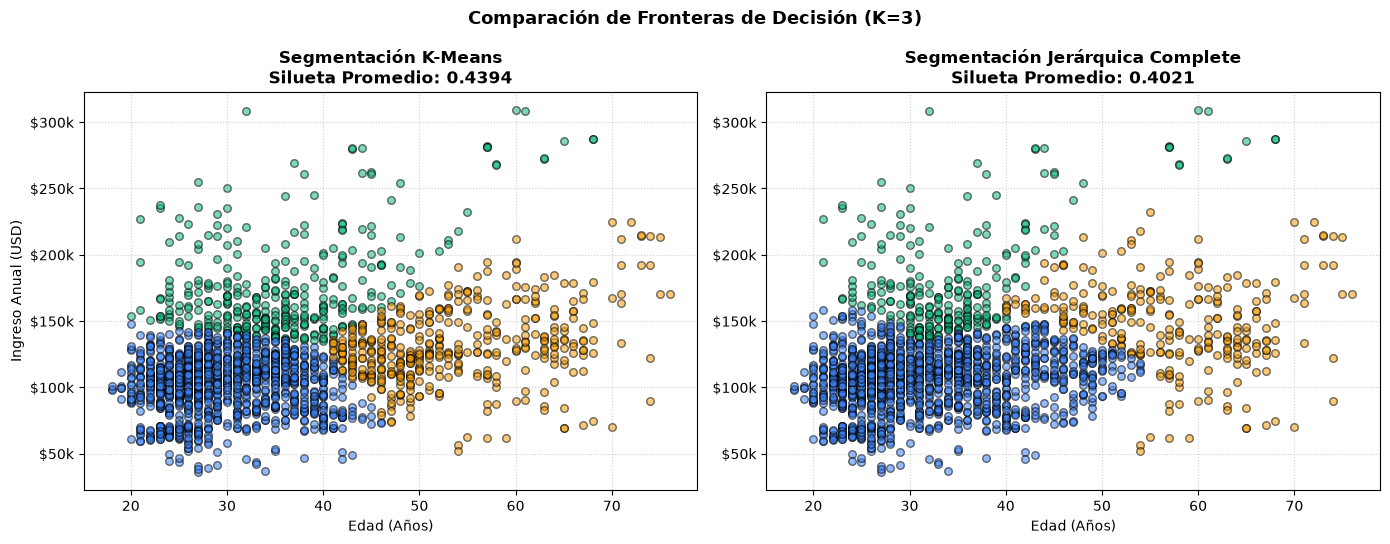

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

Z = linkage(columnas_escaladas, method='complete', metric='euclidean')
print("Últimas Fusiones")
for i in range(1, 6):
    idx = -i
    c1, c2, dist, count = Z[idx]
    paso = len(columnas_escaladas) - i
    print(f"Paso {paso}: Clúster {int(c1)} + Clúster {int(c2)} -> Distancia de fusión: {dist:.4f} ({int(count)} elementos)")

plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True, color_threshold=5.7, above_threshold_color='#4B5563')
plt.axhline(y=5.7, color='red', linestyle='--', linewidth=2, label='Nivel de Corte Propuesto (y=5.7)')
plt.title('Dendrograma - Enlace Completo (Complete Linkage)', fontsize=12, fontweight='bold')
plt.xlabel('Observaciones (Clientes)')
plt.ylabel('Distancia Euclídea')
plt.legend()
plt.tight_layout()
plt.show()



# Ajustar K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(columnas_escaladas)
sil_km = silhouette_score(columnas_escaladas, labels_km)

# Ajustar Jerárquico Aglomerativo (K=3)
ac = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete')
labels_ac = ac.fit_predict(columnas_escaladas)
sil_ac = silhouette_score(columnas_escaladas, labels_ac)

print(f"Coefiecientes de Silueta Promedio con K = 3")
print(f"Coeficiente de Silueta - K-Means: {sil_km:.4f}")
print(f"Coeficiente de Silueta - Jerárquico Aglomerativo: {sil_ac:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
colores_km = {0: '#10B981', 1: '#3B82F6', 2: '#F59E0B'}
colores_ac = {0: '#10B981', 1: '#F59E0B', 2: '#3B82F6'}

for c_id in np.unique(labels_km):
    sub = clientes_df[labels_km == c_id]
    axs[0].scatter(sub['Age'], sub['Income'], color=colores_km[c_id], alpha=0.55, edgecolors='k', s=30)
axs[0].set_title(f'Segmentación K-Means\nSilueta Promedio: {sil_km:.4f}', fontweight='bold')
axs[0].set_xlabel('Edad (Años)')
axs[0].set_ylabel('Ingreso Anual (USD)')
axs[0].grid(True, linestyle=':', alpha=0.6)

for c_id in np.unique(labels_ac):
    sub = clientes_df[labels_ac == c_id]
    axs[1].scatter(sub['Age'], sub['Income'], color=colores_ac[c_id], alpha=0.55, edgecolors='k', s=30)
axs[1].set_title(f'Segmentación Jerárquica Complete\nSilueta Promedio: {sil_ac:.4f}', fontweight='bold')
axs[1].set_xlabel('Edad (Años)')
axs[1].grid(True, linestyle=':', alpha=0.6)


import matplotlib.ticker as ticker
for ax in axs:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

plt.suptitle('Comparación de Fronteras de Decisión (K=3)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 8. Análisis final

A partir de todo el procedimiento, responda:

1. ¿Qué valor de $K$ considera más adecuado para K-Means? Fundamente utilizando WCSS, silueta e interpretación de los clusters.
2. ¿Qué perfiles de clientes identifica?
3. ¿Qué diferencias encuentra entre K-Means y el agrupamiento jerárquico?
4. ¿Qué limitación introduce construir los clusters únicamente con `Age` e `Income`?
5. ¿Por qué no sería correcto afirmar que los clusters encontrados son las únicas categorías posibles de clientes?

8.1: Consideramos que K = 3 es el valor más adecuaco, considerando que la inercia tiene una bajada abrupta desde K = 1 a K = 3, luego de este punto el descenso empieza a volverse marginal.

El promedio de silueta también es otro valor que da indicios que permiten identificar a K = 3 como el valor óptimo, si bien no es el más alto, no tiene una diferencia mucho mayor con K = 2 que la que tiene con los valores mayores o iguales a 4, demostrando que forzar una división con más de tres grupos deteriora la cohesión y separación de los conjuntos.

Si bien el valor de silueta promedio en K = 2 es ligeramente más altoa, una segmentación en dos grupos resulta comercialmente burdo e inútil, limitando a separar el set en jóvenes de adultos o bien en personas de ingresos bajos de altos. La solución de K = 3 ofrece una estructura balanceada de tamaño que divide el mercado en perfiles más accionables y con un mayor valor estratégico.



8.2: Como ha sido refereido en la actividad 6, se destacan 3 clústers:
* Clúster 0: Profesionales exitosos, representando un 17,35% del set
* Clúster 1: Jóvenes de consumo masivo, representando un 60.9%
* Clúster 2: Adultos mayores establecidos, representando un 21,75% de la población



8.3: K-Means es un método iterativo que busca centroides para cada grupo, lo que le permite reasignar puntos continuamente y lograr un coeficiente de silueta superior. En cambio, el agrupamiento jerárquico es determinista e irreversible: une los datos de abajo hacia arriba de forma definitiva y arrastra rigideces que bajan su silueta. Visualmente, K-Means dibuja fronteras rectas y simétricas, mientras que el jerárquico las deforma de manera irregular para evitar que queden puntos muy lejanos en un mismo grupo. Además, para el negocio, K-Means es lineal y rápido (ideal para millones de clientes), mientras que el jerárquico es sumamente lento y pesado porque calcula distancias de todos contra todos, volviéndose inviable a gran escala. 



8.4: Basar el estudio en esas dos variables puede dejar problemas tales como la pérdida de dimensionalidad comportamental, al ignorar hábitos y comportamientos de compra específicos, o sea, dos clientes con la misma edad e ingreso podrían tener perfiles psicográficos opuestos.
Al segmentar solo con estas dos variables continuas se reduce el estuido a un mapa socioeconómico estándar.
También se ignora el dinamismo transaccional al no considerar variables clave de interacción con el negocio


8.5: No existe una única segmentación "natural" porque el proceso es altamente subjetivo; cambiar decisiones de diseño como el algoritmo, la métrica de distancia o el método de escalado generaría grupos totalmente distintos. Además, un clúster es solo una foto temporal de un mercado dinámico que cambia constantemente por inflación, modas o competencia, lo que altera el comportamiento de compra a lo largo del tiempo. Por último, la clasificación siempre depende del objetivo de negocio, ya que un mismo cliente puede pertenecer simultáneamente a distintos grupos según se analice su riesgo crediticio, su lealtad de marca o su nivel de digitalización, sin que una sola de estas miradas sea la única correcta